In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import pandas as pd

project_folder = Path(
    "/content/drive/MyDrive/Dude_Wheres_My_Bike_Project"
)

geo_raw = project_folder / "01_Data" / "geographic_lookup" / "raw"

print("Folder exists:", geo_raw.exists())

Folder exists: True


In [ ]:
all_files = [file for file in geo_raw.rglob("*") if file.is_file()]

print("Number of files:", len(all_files))

for file in all_files:
    print(file.relative_to(geo_raw))

Number of files: 16
lor_2021-01-01_k3_uebersicht_id_namen.xlsx
lor_2021-01-01_k3_shapefiles_nur_id/LOR_2023-01-01_BZR_EPSG_25833_nur_ID.cpg
lor_2021-01-01_k3_shapefiles_nur_id/LOR_2023-01-01_BZR_EPSG_25833_nur_ID.shx
lor_2021-01-01_k3_shapefiles_nur_id/LOR_2023-01-01_BZR_EPSG_25833_nur_ID.prj
lor_2021-01-01_k3_shapefiles_nur_id/LOR_2023-01-01_BZR_EPSG_25833_nur_ID.shp
lor_2021-01-01_k3_shapefiles_nur_id/LOR_2023-01-01_BZR_EPSG_25833_nur_ID.dbf
lor_2021-01-01_k3_shapefiles_nur_id/LOR_2023-01-01_PGR_EPSG_25833_nur_ID.prj
lor_2021-01-01_k3_shapefiles_nur_id/LOR_2023-01-01_PGR_EPSG_25833_nur_ID.cpg
lor_2021-01-01_k3_shapefiles_nur_id/LOR_2023-01-01_PGR_EPSG_25833_nur_ID.shx
lor_2021-01-01_k3_shapefiles_nur_id/LOR_2023-01-01_PGR_EPSG_25833_nur_ID.dbf
lor_2021-01-01_k3_shapefiles_nur_id/LOR_2023-01-01_PGR_EPSG_25833_nur_ID.shp
lor_2021-01-01_k3_shapefiles_nur_id/LOR_2023-01-01_PLR_EPSG_25833_nur_ID.prj
lor_2021-01-01_k3_shapefiles_nur_id/LOR_2023-01-01_PLR_EPSG_25833_nur_ID.cpg
lor_2021-01-0

In [ ]:
excel_files = list(geo_raw.rglob("*.xlsx"))
shape_files = list(geo_raw.rglob("*.shp"))

print("Excel files:")
for file in excel_files:
    print(file.name)

print("\nShapefiles:")
for file in shape_files:
    print(file.name)

Excel files:
lor_2021-01-01_k3_uebersicht_id_namen.xlsx

Shapefiles:
LOR_2023-01-01_BZR_EPSG_25833_nur_ID.shp
LOR_2023-01-01_PGR_EPSG_25833_nur_ID.shp
LOR_2023-01-01_PLR_EPSG_25833_nur_ID.shp


In [ ]:
lor_excel = excel_files[0]

workbook = pd.ExcelFile(lor_excel)

print("File:", lor_excel.name)
print("Sheets:", workbook.sheet_names)

File: lor_2021-01-01_k3_uebersicht_id_namen.xlsx
Sheets: ['Inhalt', 'LOR_2023_Übersicht', 'LOR_2023_BEZ', 'LOR_2023_PGR', 'LOR_2023_BZR', 'LOR_2023_PLR']


In [ ]:
for sheet in workbook.sheet_names:
    preview = pd.read_excel(
        lor_excel,
        sheet_name=sheet,
        dtype=str
    )

    print("\n--------------------")
    print("Sheet:", sheet)
    print("Rows and columns:", preview.shape)
    print("Columns:", preview.columns.tolist())
    display(preview.head())



--------------------
Sheet: Inhalt
Rows and columns: (6, 2)
Columns: ['Titel:', 'Lebensweltlich orientierte Räume (LOR), Modifikation vom 01.01.2021']


,Titel:,"Lebensweltlich orientierte Räume (LOR), Modifikation vom 01.01.2021"
0,Datenstand:,01.01.2023 (inkl. Änderungsmitteilung 03)
1,Systematik:,12 Bezirke (BEZ)
2,NaN,58 Prognoseräume (PGR) als obere LOR-Ebene
3,NaN,143 Bezirksregione (BZR) als mittlere LOR-Ebene
4,NaN,542 Planungsräume (PLR) als untere LOR-Ebene



--------------------
Sheet: LOR_2023_Übersicht
Rows and columns: (542, 10)
Columns: ['BLN_ID', 'BLN', 'BEZ_ID', 'BEZ', 'PGR_ID', 'PGR', 'BZR_ID', 'BZR', 'PLR_ID', 'PLR']


,BLN_ID,BLN,BEZ_ID,BEZ,PGR_ID,PGR,BZR_ID,BZR,PLR_ID,PLR
0,00,Berlin,01,Mitte,0110,Zentrum,011001,Tiergarten Süd,01100101,Stülerstraße
1,00,Berlin,01,Mitte,0110,Zentrum,011001,Tiergarten Süd,01100102,Großer Tiergarten
2,00,Berlin,01,Mitte,0110,Zentrum,011001,Tiergarten Süd,01100103,Lützowstraße
3,00,Berlin,01,Mitte,0110,Zentrum,011001,Tiergarten Süd,01100104,Körnerstraße
4,00,Berlin,01,Mitte,0110,Zentrum,011002,Regierungsviertel,01100205,Wilhelmstraße



--------------------
Sheet: LOR_2023_BEZ
Rows and columns: (12, 2)
Columns: ['BEZ_ID', 'BEZ_NAME']


...

,PGR_ID,PGR_Name
0,0110,Zentrum
1,0120,Moabit
2,0130,Gesundbrunnen
3,0140,Wedding
4,0210,Kreuzberg Nord



--------------------
Sheet: LOR_2023_BZR
Rows and columns: (143, 2)
Columns: ['BZR_ID', 'BZR_Name']


,BZR_ID,BZR_Name
0,011001,Tiergarten Süd
1,011002,Regierungsviertel
2,011003,Alexanderplatz
3,011004,Brunnenstraße Süd
4,012005,Moabit West



--------------------
Sheet: LOR_2023_PLR
Rows and columns: (542, 2)
Columns: ['PLR_ID', 'PLR_Name']


,PLR_ID,PLR_Name
0,01100101,Stülerstraße
1,01100102,Großer Tiergarten
2,01100103,Lützowstraße
3,01100104,Körnerstraße
4,01100205,Wilhelmstraße


In [ ]:
lor_lookup = pd.read_excel(
    lor_excel,
    sheet_name="LOR_2023_Übersicht",
    dtype=str
)

print("Shape:", lor_lookup.shape)
display(lor_lookup.head())

Shape: (542, 10)


,BLN_ID,BLN,BEZ_ID,BEZ,PGR_ID,PGR,BZR_ID,BZR,PLR_ID,PLR
0,00,Berlin,01,Mitte,0110,Zentrum,011001,Tiergarten Süd,01100101,Stülerstraße
1,00,Berlin,01,Mitte,0110,Zentrum,011001,Tiergarten Süd,01100102,Großer Tiergarten
2,00,Berlin,01,Mitte,0110,Zentrum,011001,Tiergarten Süd,01100103,Lützowstraße
3,00,Berlin,01,Mitte,0110,Zentrum,011001,Tiergarten Süd,01100104,Körnerstraße
4,00,Berlin,01,Mitte,0110,Zentrum,011002,Regierungsviertel,01100205,Wilhelmstraße


In [ ]:
lor_lookup_clean = lor_lookup.rename(
    columns={
        "BLN_ID": "state_id",
        "BLN": "state_name",
        "BEZ_ID": "district_id",
        "BEZ": "district_name",
        "PGR_ID": "forecast_area_id",
        "PGR": "forecast_area_name",
        "BZR_ID": "district_region_id",
        "BZR": "district_region_name",
        "PLR_ID": "lor",
        "PLR": "planning_area_name"
    }
).copy()

In [ ]:
for column in lor_lookup_clean.columns:
    lor_lookup_clean[column] = (
        lor_lookup_clean[column]
        .astype("string")
        .str.strip()
    )

In [ ]:
print("Rows:", len(lor_lookup_clean))
print("Unique LOR codes:", lor_lookup_clean["lor"].nunique())
print("Missing LOR codes:", lor_lookup_clean["lor"].isna().sum())
print("Duplicate LOR codes:", lor_lookup_clean["lor"].duplicated().sum())

print("\nCode lengths:")
print(lor_lookup_clean["lor"].str.len().value_counts().sort_index())

display(lor_lookup_clean.head())

Rows: 542
Unique LOR codes: 542
Missing LOR codes: 0
Duplicate LOR codes: 0

Code lengths:
lor
8    542
Name: count, dtype: Int64


,state_id,state_name,district_id,district_name,forecast_area_id,forecast_area_name,district_region_id,district_region_name,lor,planning_area_name
0,00,Berlin,01,Mitte,0110,Zentrum,011001,Tiergarten Süd,01100101,Stülerstraße
1,00,Berlin,01,Mitte,0110,Zentrum,011001,Tiergarten Süd,01100102,Großer Tiergarten
2,00,Berlin,01,Mitte,0110,Zentrum,011001,Tiergarten Süd,01100103,Lützowstraße
3,00,Berlin,01,Mitte,0110,Zentrum,011001,Tiergarten Süd,01100104,Körnerstraße
4,00,Berlin,01,Mitte,0110,Zentrum,011002,Regierungsviertel,01100205,Wilhelmstraße


In [ ]:
assert len(lor_lookup_clean) == 542
assert lor_lookup_clean["lor"].nunique() == 542
assert lor_lookup_clean["lor"].isna().sum() == 0
assert lor_lookup_clean["lor"].duplicated().sum() == 0
assert lor_lookup_clean["lor"].str.len().eq(8).all()

print("All lookup checks passed!")

All lookup checks passed!


In [ ]:
geo_processed = (
    project_folder
    / "01_Data"
    / "geographic_lookup"
    / "processed"
)

geo_processed.mkdir(parents=True, exist_ok=True)

In [ ]:
lookup_output = geo_processed / "lor_lookup_2023_clean.csv"

lor_lookup_clean.to_csv(
    lookup_output,
    index=False,
    encoding="utf-8-sig"
)

print("Saved to:")
print(lookup_output)

Saved to:
/content/drive/MyDrive/Dude_Wheres_My_Bike_Project/01_Data/geographic_lookup/processed/lor_lookup_2023_clean.csv


In [ ]:
import geopandas as gpd

In [ ]:
plr_shapefiles = [
    file for file in shape_files
    if "_PLR_" in file.name
]

print(plr_shapefiles)

[PosixPath('/content/drive/MyDrive/Dude_Wheres_My_Bike_Project/01_Data/geographic_lookup/raw/lor_2021-01-01_k3_shapefiles_nur_id/LOR_2023-01-01_PLR_EPSG_25833_nur_ID.shp')]


In [ ]:
plr_shp = plr_shapefiles[0]
plr_geo = gpd.read_file(plr_shp)

print("Shape:", plr_geo.shape)
print("Coordinate system:", plr_geo.crs)
print("Columns:", plr_geo.columns.tolist())

display(plr_geo.head())

Shape: (542, 2)
Coordinate system: EPSG:25833
Columns: ['PLR_ID', 'geometry']


,PLR_ID,geometry
0,08401245,"POLYGON ((397994.196 5806511.717, 397993.956 5..."
1,08401244,"POLYGON ((398223.6 5807886.46, 398227.359 5807..."
2,08401246,"POLYGON ((397747.159 5808365.587, 397773.792 5..."
3,08401243,"POLYGON ((397023.73 5809326.07, 397109.311 580..."
4,08401242,"POLYGON ((397023.73 5809326.07, 397041.045 580..."


<Axes: >

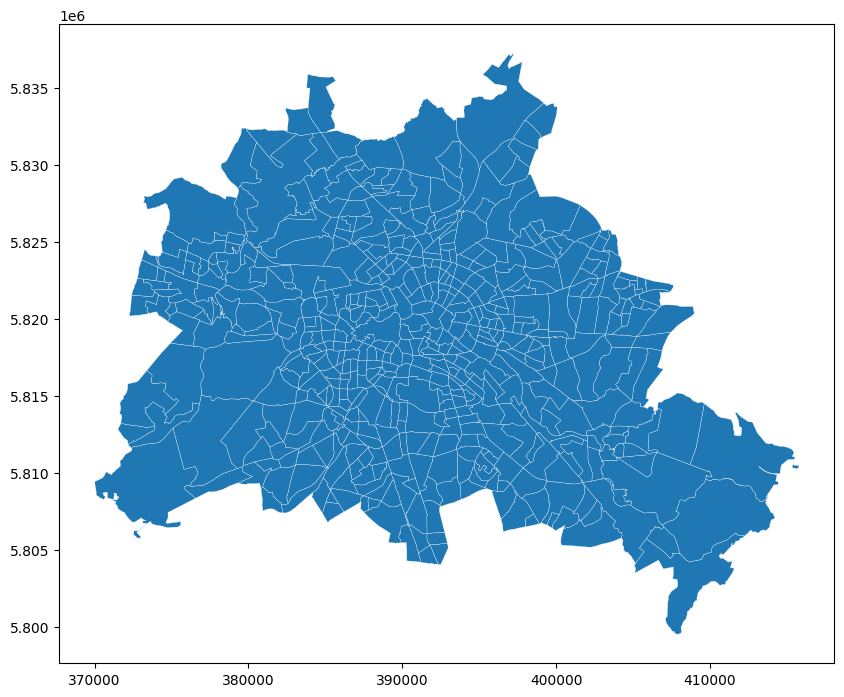

In [ ]:
plr_geo.plot(
    figsize=(10, 10),
    edgecolor="white",
    linewidth=0.2
)

In [ ]:
print(plr_geo.shape)
print(plr_geo.crs)
print(plr_geo.columns.tolist())
display(plr_geo.head())

(542, 2)
EPSG:25833
['PLR_ID', 'geometry']


,PLR_ID,geometry
0,08401245,"POLYGON ((397994.196 5806511.717, 397993.956 5..."
1,08401244,"POLYGON ((398223.6 5807886.46, 398227.359 5807..."
2,08401246,"POLYGON ((397747.159 5808365.587, 397773.792 5..."
3,08401243,"POLYGON ((397023.73 5809326.07, 397109.311 580..."
4,08401242,"POLYGON ((397023.73 5809326.07, 397041.045 580..."


In [ ]:
plr_geo["PLR_ID"] = (
    plr_geo["PLR_ID"]
    .astype("string")
    .str.strip()
    .str.zfill(8)
)

print(plr_geo["PLR_ID"].str.len().value_counts())
print("Unique codes:", plr_geo["PLR_ID"].nunique())
print("Duplicates:", plr_geo["PLR_ID"].duplicated().sum())

PLR_ID
8    542
Name: count, dtype: Int64
Unique codes: 542
Duplicates: 0


In [ ]:
plr_named = plr_geo.merge(
    lor_lookup_clean,
    left_on="PLR_ID",
    right_on="lor",
    how="left",
    validate="one_to_one",
    indicator=True
)

print("Rows after join:", len(plr_named))
print("\nJoin results:")
print(plr_named["_merge"].value_counts())

display(
    plr_named[
        [
            "PLR_ID",
            "planning_area_name",
            "district_region_name",
            "forecast_area_name",
            "district_name"
        ]
    ].head()
)

Rows after join: 542

Join results:
_merge
both          542
left_only       0
right_only      0
Name: count, dtype: int64


,PLR_ID,planning_area_name,district_region_name,forecast_area_name,district_name
0,08401245,Frauenviertel,Rudow,Buckow Nord/Rudow,Neukölln
1,08401244,Waßmannsdorfer Chaussee,Rudow,Buckow Nord/Rudow,Neukölln
2,08401246,Waltersdorfer Chaussee Ost,Rudow,Buckow Nord/Rudow,Neukölln
3,08401243,Alt-Rudow,Rudow,Buckow Nord/Rudow,Neukölln
4,08401242,Zittauer Straße,Rudow,Buckow Nord/Rudow,Neukölln


In [ ]:
plr_named = plr_named.drop(columns="_merge")

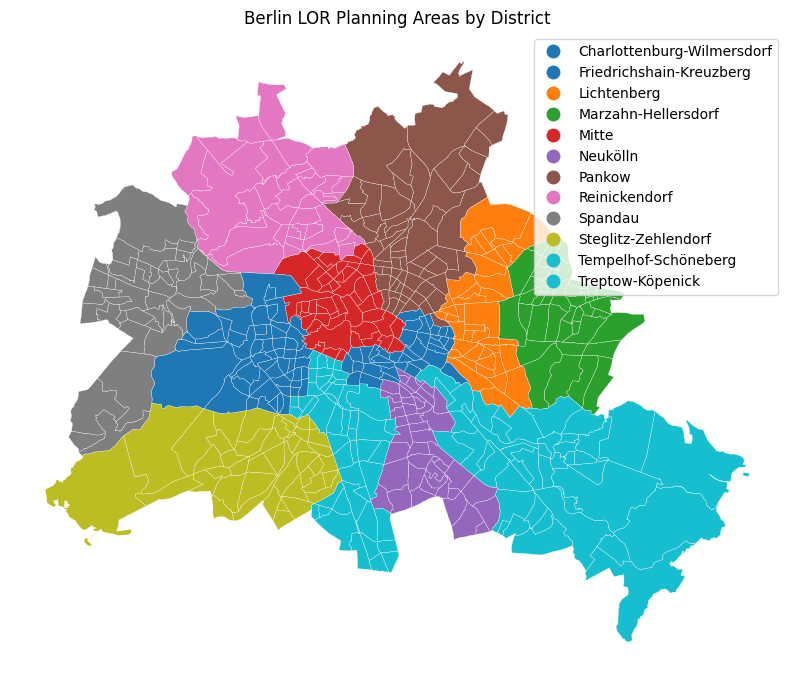

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

plr_named.plot(
    ax=ax,
    column="district_name",
    edgecolor="white",
    linewidth=0.2,
    legend=True,
    categorical=True
)

ax.set_title("Berlin LOR Planning Areas by District")
ax.set_axis_off()

plt.show()

In [ ]:
plr_tableau = plr_named.to_crs(epsg=4326)

print("New coordinate system:", plr_tableau.crs)

New coordinate system: EPSG:4326


In [ ]:
geojson_output = (
    geo_processed
    / "berlin_lor_planning_areas_2023_named.geojson"
)

plr_tableau.to_file(
    geojson_output,
    driver="GeoJSON"
)

print("Saved to:")
print(geojson_output)

Saved to:
/content/drive/MyDrive/Dude_Wheres_My_Bike_Project/01_Data/geographic_lookup/processed/berlin_lor_planning_areas_2023_named.geojson


In [ ]:
join_report = pd.DataFrame({
    "check": [
        "Official planning areas",
        "Geographic shapes",
        "Unique geographic codes",
        "Matched geographic shapes",
        "Unmatched geographic shapes",
        "Missing planning-area names",
        "Original coordinate system",
        "Export coordinate system"
    ],
    "result": [
        len(lor_lookup_clean),
        len(plr_geo),
        plr_geo["PLR_ID"].nunique(),
        plr_named["planning_area_name"].notna().sum(),
        plr_named["planning_area_name"].isna().sum(),
        plr_named["planning_area_name"].isna().sum(),
        str(plr_geo.crs),
        str(plr_tableau.crs)
    ]
})

display(join_report)

,check,result
0,Official planning areas,542
1,Geographic shapes,542
2,Unique geographic codes,542
3,Matched geographic shapes,542
4,Unmatched geographic shapes,0
5,Missing planning-area names,0
6,Original coordinate system,EPSG:25833
7,Export coordinate system,EPSG:4326


In [ ]:
report_output = geo_processed / "lor_join_report.csv"

join_report.to_csv(
    report_output,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", report_output)

Saved: /content/drive/MyDrive/Dude_Wheres_My_Bike_Project/01_Data/geographic_lookup/processed/lor_join_report.csv


In [ ]:
geojson_check = gpd.read_file(geojson_output)

print("Rows:", len(geojson_check))
print("CRS:", geojson_check.crs)
print("Columns:", geojson_check.columns.tolist())
print("Missing geometries:", geojson_check.geometry.isna().sum())

assert len(geojson_check) == 542
assert geojson_check.crs.to_epsg() == 4326
assert geojson_check.geometry.isna().sum() == 0

print("GeoJSON export passed all checks!")

Rows: 542
CRS: EPSG:4326
Columns: ['PLR_ID', 'state_id', 'state_name', 'district_id', 'district_name', 'forecast_area_id', 'forecast_area_name', 'district_region_id', 'district_region_name', 'lor', 'planning_area_name', 'geometry']
Missing geometries: 0
GeoJSON export passed all checks!


In [45]:
cleaned_v1_path = (
    project_folder
    / "01_Data"
    / "processed"
    / "cleaned_v1 (3).csv"
)

bike_data = pd.read_csv(
    cleaned_v1_path,
    dtype={"lor": "string"}
)

print("Shape:", bike_data.shape)
print("Columns:", bike_data.columns.tolist())
display(bike_data.head())

Shape: (26965, 27)
Columns: ['record_created_date', 'offence_start_date', 'offence_start_hour', 'offence_end_date', 'offence_end_hour', 'lor', 'reported_damage_eur', 'attempt', 'bicycle_type', 'offence_category', 'recording_reason', 'offence_start', 'offence_end', 'offence_window_hours', 'year', 'month_number', 'month_name', 'weekday_number', 'weekday_name', 'is_weekend', 'is_attempt', 'is_attempt_unknown', 'is_zero_damage', 'is_cellar_burglary', 'is_cellar_location', 'is_duplicate_copy', 'is_comparable_ytd']


,record_created_date,offence_start_date,offence_start_hour,offence_end_date,offence_end_hour,lor,reported_damage_eur,attempt,bicycle_type,offence_category,...,weekday_number,weekday_name,is_weekend,is_attempt,is_attempt_unknown,is_zero_damage,is_cellar_burglary,is_cellar_location,is_duplicate_copy,is_comparable_ytd
0,2026-08-08,2026-08-08,0,2026-08-08,0,01200521,0,Ja,Rennrad,Fahrraddiebstahl,...,5,Saturday,True,True,False,True,False,False,False,True
1,2026-08-08,2026-08-01,11,2026-08-01,13,03601347,2150,Nein,Citybike,Fahrraddiebstahl,...,5,Saturday,True,False,False,False,False,False,False,True
2,2026-08-08,2026-08-08,0,2026-08-08,0,01200521,0,Ja,Rennrad,Fahrraddiebstahl,...,5,Saturday,True,True,False,True,False,False,True,True
3,2026-08-08,2026-08-05,11,2026-08-05,17,03701554,2650,Nein,Herrenfahrrad,Fahrraddiebstahl,...,2,Wednesday,False,False,False,False,False,False,False,True
4,2026-08-08,2026-08-08,12,2026-08-08,17,11401034,1499,Nein,Rennrad,Fahrraddiebstahl,...,5,Saturday,True,False,False,False,False,False,False,True


In [46]:
print("Missing LOR codes:", bike_data["lor"].isna().sum())
print("Unique LOR codes:", bike_data["lor"].nunique())

print("\nLOR-code lengths:")
print(
    bike_data["lor"]
    .str.strip()
    .str.len()
    .value_counts(dropna=False)
    .sort_index()
)

Missing LOR codes: 0
Unique LOR codes: 534

LOR-code lengths:
lor
8    26965
Name: count, dtype: Int64


In [47]:
bike_join_test = bike_data.copy()
bike_join_test["lor"] = bike_join_test["lor"].str.strip()

bike_join_test = bike_join_test.merge(
    lor_lookup_clean,
    on="lor",
    how="left",
    validate="many_to_one",
    indicator=True
)

print("Rows before join:", len(bike_data))
print("Rows after join:", len(bike_join_test))
print("\nJoin results:")
print(bike_join_test["_merge"].value_counts())

Rows before join: 26965
Rows after join: 26965

Join results:
_merge
both          26965
left_only         0
right_only        0
Name: count, dtype: int64


In [49]:
unmatched_rows = bike_join_test[
    bike_join_test["_merge"] == "left_only"
].copy()

unmatched_codes = (
    unmatched_rows
    .groupby("lor", dropna=False)
    .size()
    .reset_index(name="report_count")
    .sort_values("report_count", ascending=False)
)

print("Unmatched records:", len(unmatched_rows))
print("Distinct unmatched codes:", len(unmatched_codes))
display(unmatched_codes)

Unmatched records: 0
Distinct unmatched codes: 0


,lor,report_count


In [50]:
join_summary = pd.DataFrame({
    "check": [
        "Bicycle records before join",
        "Bicycle records after join",
        "Matched records",
        "Unmatched records",
        "Distinct bicycle LOR codes",
        "Distinct unmatched LOR codes",
        "Official planning areas",
        "Official areas without reports"
    ],
    "result": [
        len(bike_data),
        len(bike_join_test),
        (bike_join_test["_merge"] == "both").sum(),
        (bike_join_test["_merge"] == "left_only").sum(),
        bike_data["lor"].nunique(),
        len(unmatched_codes),
        lor_lookup_clean["lor"].nunique(),
        lor_lookup_clean["lor"].nunique() - bike_data["lor"].nunique()
    ]
})

display(join_summary)

join_summary.to_csv(
    geo_processed / "cleaned_v1_lor_join_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

unmatched_codes.to_csv(
    geo_processed / "cleaned_v1_unmatched_lor_codes.csv",
    index=False,
    encoding="utf-8-sig"
)

,check,result
0,Bicycle records before join,26965
1,Bicycle records after join,26965
2,Matched records,26965
3,Unmatched records,0
4,Distinct bicycle LOR codes,534
5,Distinct unmatched LOR codes,0
6,Official planning areas,542
7,Official areas without reports,8


In [51]:
geographic_columns = [
    "district_id",
    "district_name",
    "forecast_area_id",
    "forecast_area_name",
    "district_region_id",
    "district_region_name",
    "planning_area_name"
]

analysis_ready_v2 = bike_join_test[
    bike_data.columns.tolist() + geographic_columns
].copy()

print("Shape:", analysis_ready_v2.shape)
print("Columns:", analysis_ready_v2.columns.tolist())
display(analysis_ready_v2.head())

Shape: (26965, 34)
Columns: ['record_created_date', 'offence_start_date', 'offence_start_hour', 'offence_end_date', 'offence_end_hour', 'lor', 'reported_damage_eur', 'attempt', 'bicycle_type', 'offence_category', 'recording_reason', 'offence_start', 'offence_end', 'offence_window_hours', 'year', 'month_number', 'month_name', 'weekday_number', 'weekday_name', 'is_weekend', 'is_attempt', 'is_attempt_unknown', 'is_zero_damage', 'is_cellar_burglary', 'is_cellar_location', 'is_duplicate_copy', 'is_comparable_ytd', 'district_id', 'district_name', 'forecast_area_id', 'forecast_area_name', 'district_region_id', 'district_region_name', 'planning_area_name']


,record_created_date,offence_start_date,offence_start_hour,offence_end_date,offence_end_hour,lor,reported_damage_eur,attempt,bicycle_type,offence_category,...,is_cellar_location,is_duplicate_copy,is_comparable_ytd,district_id,district_name,forecast_area_id,forecast_area_name,district_region_id,district_region_name,planning_area_name
0,2026-08-08,2026-08-08,0,2026-08-08,0,01200521,0,Ja,Rennrad,Fahrraddiebstahl,...,False,False,True,01,Mitte,0120,Moabit,012005,Moabit West,Zwinglistraße
1,2026-08-08,2026-08-01,11,2026-08-01,13,03601347,2150,Nein,Citybike,Fahrraddiebstahl,...,False,False,True,03,Pankow,0360,Nördlicher Prenzlauer Berg,036013,Helmholtzplatz,Helmholtzplatz
2,2026-08-08,2026-08-08,0,2026-08-08,0,01200521,0,Ja,Rennrad,Fahrraddiebstahl,...,False,True,True,01,Mitte,0120,Moabit,012005,Moabit West,Zwinglistraße
3,2026-08-08,2026-08-05,11,2026-08-05,17,03701554,2650,Nein,Herrenfahrrad,Fahrraddiebstahl,...,False,False,True,03,Pankow,0370,Südlicher Prenzlauer Berg,037015,Prenzlauer Berg Südwest,Teutoburger Platz
4,2026-08-08,2026-08-08,12,2026-08-08,17,11401034,1499,Nein,Rennrad,Fahrraddiebstahl,...,False,False,True,11,Lichtenberg,1140,Lichtenberg Mitte,114010,Friedrichsfelde Nord,Tierpark


In [52]:
assert len(analysis_ready_v2) == 26965
assert analysis_ready_v2.shape[1] == 34
assert analysis_ready_v2["lor"].isna().sum() == 0
assert analysis_ready_v2["lor"].str.len().eq(8).all()
assert analysis_ready_v2["planning_area_name"].isna().sum() == 0
assert analysis_ready_v2["district_name"].isna().sum() == 0

print("analysis_ready_v2 passed all checks!")

analysis_ready_v2 passed all checks!


In [53]:
print("Districts:", analysis_ready_v2["district_name"].nunique())
print("Planning areas represented:", analysis_ready_v2["lor"].nunique())
print("Rows:", len(analysis_ready_v2))

Districts: 12
Planning areas represented: 534
Rows: 26965


In [54]:
analysis_ready_path = (
    project_folder
    / "01_Data"
    / "processed"
    / "analysis_ready_v2.csv"
)

analysis_ready_v2.to_csv(
    analysis_ready_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved to:", analysis_ready_path)

Saved to: /content/drive/MyDrive/Dude_Wheres_My_Bike_Project/01_Data/processed/analysis_ready_v2.csv


In [55]:
v2_check = pd.read_csv(
    analysis_ready_path,
    dtype={
        "lor": "string",
        "district_id": "string",
        "forecast_area_id": "string",
        "district_region_id": "string"
    }
)

assert v2_check.shape == (26965, 34)
assert v2_check["lor"].str.len().eq(8).all()
assert v2_check["district_name"].isna().sum() == 0

print("Saved analysis_ready_v2.csv passed verification!")

Saved analysis_ready_v2.csv passed verification!
